# SoftUni Machine Learning (May 2026) Final Project

## Credit Clustering Tool Using SEC EDGAR Data for US Public Companies
## Kamen Dimitrov, CFA



In [1]:
#Import your libraries here

import os
import sys
from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

pd.set_option("display.max_rows", 300)
pd.set_option("display.max_columns", 160)
pd.set_option("display.max_colwidth", 160)

In [2]:
# Notebook configuration

BASE_URL = "https://pub-a6c3a3e1a0f546beb4be7cc34fd647d1.r2.dev/raw_financial_facts_parquet"

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DUCKDB_DIR = PROJECT_ROOT / "data" / "duckdb"
DUCKDB_DIR.mkdir(parents=True, exist_ok=True)

DB_PATH = DUCKDB_DIR / "financials.duckdb"

OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

MODEL_DIR = OUTPUT_DIR / "saved_models"
MODEL_DIR.mkdir(exist_ok=True)

CURRENT_OUTPUT_DIR = OUTPUT_DIR / "credit_clustering_outputs_v3"
CURRENT_OUTPUT_DIR.mkdir(exist_ok=True)

ARTIFACT_PATH = MODEL_DIR / "nonfinancial_credit_scorecard_kmeans_k5_v3.joblib"

In [3]:
#Import your modules here

from src.credit_clustering import (
    # Config
    PUBLIC_COMPANY_MIN_ASSETS,
    SCORECARD_CLUSTER_FEATURES,
    SCORECARD_COMPONENT_FEATURES,
    RATIO_COLS,
    INTERPRET_FEATURES,
    DEFAULT_SEGMENT_COL,
    DEFAULT_TARGET_SEGMENTS,
    DEFAULT_N_CLUSTERS,
    DEFAULT_MIN_ROWS_PER_SEGMENT,
    cluster_segments,

    # EDGAR concepts and panel construction
    EDGAR_CONCEPT_MAP,
    create_issuer_year_facts_table,
    build_issuer_year_panel,

    # Feature engineering
    engineer_private_company_features,

    # Clustering
    cluster_segments,
    evaluate_segments_k_range,

    # Profiling
    build_cluster_profile,
    build_cluster_medians,
    build_feature_extremes,
    build_industry_cluster_mix,
    add_rating_style_labels,
    build_rating_label_maps,
    representatives,
    merge_profile_with_representatives,

    # Artifacts
    build_credit_clustering_artifact,
    save_artifact,
    summarize_artifact,

    #Config settings
    DEFAULT_N_CLUSTERS,
    DEFAULT_RANDOM_STATE,
    DEFAULT_N_INIT,
)

## Introduction:

As a finance professional, I have devoted a significant portion of my 20+ years of career development to corporate financial statement analysis, assessing the credit health of corporate issuers, assigning risk metrics, and performing various credit evaluations. As a credit analyst, as well as a decision maker in such situations, I have developed a structured approach towards assessing the credit health of various businesses. With large public companies, this is usually easier, as they often obtain their own credit ratings from reputable agencies such as Moody's, S&P, or Fitch. Official credit ratings are not a complete substitute for performing my own credit analysis; however, they do form a solid benchmark to start with. Official credit ratings also drive capital markets for corporate bonds, especially if a company is in the lower range of investment-grade ratings (Baa/BBB/BBB from Moody's/S&P/Fitch) or the upper range of speculative-grade ratings (Ba/BB/BB respectively).

However, smaller companies rarely have their own official credit ratings, while the need to classify their credit profile becomes more apparent for various comparison purposes. Back in 2005, I first witnessed and used the results of a proprietary neural network, which was trained on public corporate data to perform the classification of the corporate credit health of issuers based on financial metrics at RBS Global Asset Management U.S. LLC, known as Voyageur Asset Management in 2005. As a result, being able to work with and construct machine learning algorithms, which could have useful applications in this direction, has been my goal, and I am finally able to do actual work in this area.

The initial idea of the project was to collect data on the official credit ratings of corporations, as well as their financial data, perform feature engineering to obtain useful credit health information, and train a classification model on the features and their relationship to the official credit ratings as labels. The final goal was to have a trained model to predict a corporate credit rating across 21 rating categories plus a default category, equivalent to the range of ratings provided by Moody's/S&P/Fitch as follows:

| Rating category | Moody's | S&P  | Fitch |
| --------------: | ------- | ---- | ----- |
|               1 | Aaa     | AAA  | AAA   |
|               2 | Aa1     | AA+  | AA+   |
|               3 | Aa2     | AA   | AA    |
|               4 | Aa3     | AA-  | AA-   |
|               5 | A1      | A+   | A+    |
|               6 | A2      | A    | A     |
|               7 | A3      | A-   | A-    |
|               8 | Baa1    | BBB+ | BBB+  |
|               9 | Baa2    | BBB  | BBB   |
|              10 | Baa3    | BBB- | BBB-  |
|              11 | Ba1     | BB+  | BB+   |
|              12 | Ba2     | BB   | BB    |
|              13 | Ba3     | BB-  | BB-   |
|              14 | B1      | B+   | B+    |
|              15 | B2      | B    | B     |
|              16 | B3      | B-   | B-    |
|              17 | Caa1    | CCC+ | CCC+  |
|              18 | Caa2    | CCC  | CCC   |
|              19 | Caa3    | CCC- | CCC-  |
|              20 | Ca      | CC   | CC    |
|              21 | C       | C    | C     |
|         Default | —       | D    | D     |

Ratings at or below Ba1/BB+/BB+ are speculative grade, commonly known as "junk," while ratings from Baa3/BBB-/BBB- and above are known as investment grade in the industry.

However, readily available labeled data became a problem; credit ratings are a major business line for each of Moody's, S&P, and Fitch. Rich datasets are hidden behind enormous paywalls - mostly Bloomberg Terminals and FactSet terminals. This temporarily paused the development of my project idea, and I explored other possibilities, thinking that here I was going to have a dead end. However, the lecture and the exercise on the topic of clustering (unsupervised learning) came, and it shed new light on this idea.

## Project Topic - Grouping Corporate Credit Profiles of US Public Companies Using Feature Engineering and K-Means Clustering

The main business-oriented goal was to perform a credit analysis on a set of public financial data downloaded from the SEC EDGAR database and to group similar credit profiles using a clustering algorithm without having official labels. The result I am seeking is to assign a relative credit score to a company, not only based on financial ratio calculations, but also a relative score based on the similarity of the company's profile to other existing companies.

My main hesitation behind this idea was that I imagine the credit space of companies to be one big imaginary cloud. If we imagine it in a 2-D or 3-D space, it would be difficult for me to artificially say where exactly one group ended and the other began. In my experience, the credit space looks more like a continuity and less like several distinctly shaped clusters or groups. This is why rating agencies have such a detailed gradient scale, and in between, they also apply `negative` or `positive` outlook labels if a company doesn't strictly adhere to one label or the other. However, I did expect to be able to meaningfully cluster the public profiles in 4 to 6 buckets, which would have a logical result-oriented interpretation.

My second hesitation was the quantity of data - the whole SEC EDGAR database, which is by far the most advanced and free source of aggregated financial data, contains a universe of about only 9000 public companies. This is why I ended up configuring my [04_obtain_model_training_data_EDGAR Notebook](04_obtain_model_training_data_EDGAR.ipynb) to be able to download the whole available database as well as update it afterwards for continuous development in the future. Furthermore, rating agencies treat credit ratings as snapshots in a given moment, i.e., the current credit rating results on the current financial metrics of the company, and I also adopted this approach - one and the same ticker has many years of financial information, and each year actually becomes its own training observation, so all of a sudden I don't have a space of just 9000 companies, but potentially I have tens of thousands of applicable observations. In this notebook below, I did put some limitations, and I also decided to work with 10-K (annual financial reports) filed only between 2020 and 2025 in order to consider their freshness. The [methodology.md file in the docs section](../docs/methodology.md) outlines the strategy of the idea implementation.

The final outcome of the project is that I have defined five groups of credit profiles, which I have ranked in order of credit quality as follows:

| Risk rank | Label                             |
| --------: | --------------------------------- |
|         1 | Strong relative credit profile    |
|         2 | Good credit profile               |
|         3 | Leveraged / elevated risk profile |
|         4 | Weak credit profile               |
|         5 | Distressed / near-default proxy   |

The K-Means algorithm is `inductive`, and as a result, I can assign a new company profile to one of the trained clusters, which is going to be the direct business benefit and useful business application in the future.

### Final introductory remark:

One additional point is important to disclose. During the project development, I was not able to identify a directly comparable modelling exercise that applies unsupervised clustering specifically to corporate credit-profile grouping in the way this project does. The available reference framework for the project therefore comes mainly from standard credit analysis, financial statement analysis, corporate finance, and general unsupervised machine learning methodology, rather than from a well-established prior model of exactly the same type.

This was honestly uncomfortable. More than once, it made me question whether I was building something meaningful or simply forcing an algorithm onto a problem where it did not belong. I spent many nights thinking through this issue, changing the feature logic, reviewing the cluster outputs, and asking myself whether the results made financial sense. In the end, I decided to present the work because the business problem is real, the financial logic behind the engineered features is transparent, and the final clusters show a meaningful credit-risk progression.

For this reason, I see the project as an exploratory, domain-guided modelling exercise with direct business application. It is not presented as an industry-standard credit rating methodology, but as a serious attempt to combine professional credit analysis with unsupervised machine learning in a practical and interpretable way, which may have direct business application.

## Limitations

This project should be interpreted as a domain-guided unsupervised credit-risk benchmarking tool, not as a formal credit rating system. The model groups companies into relative financial-risk buckets based on engineered financial statement features and K-Means clustering, supported by professional credit-analysis assumptions, scorecard logic, and diagnostic guardrails.

The main limitations are that the model is trained on SEC public-company data, does not include official rating labels or observed default outcomes (`survivorship bias`), and does not capture qualitative credit factors such as management quality, ownership support, refinancing access, market position, or country risk. It is also a point-in-time financial profile model rather than a through-the-cycle rating system. Therefore, its output should be used for screening, benchmarking, exploratory analysis, and analyst support, not as a lending decision, investment recommendation, regulatory credit assessment, or probability-of-default estimate.

These limitations do not make the model unusable. They define the correct interpretation of the results. The model is useful because it is transparent, reproducible, financially interpretable, and suitable for structured credit-risk comparison, provided that the final conclusion remains supported by professional judgment.

I have outlined a detailed description in [the limitations.md file in the docs section](../docs/limitations.md).

### Step 1. Connect to EDGAR raw facts

The raw EDGAR-derived facts are read from remote Parquet files into a DuckDB view. I keep the data in R2 storage in Cloudflare, which allows the project to avoid storing the full raw SEC dataset locally while still being able to query it efficiently during feature engineering and model-training preparation.

In [4]:
parquet_urls = [
    f"{BASE_URL}/part_{i:05d}.parquet"
    for i in range(401)
]

con = duckdb.connect(DB_PATH)

con.execute("""
INSTALL httpfs;
LOAD httpfs;
""")

con.execute(f"""
CREATE OR REPLACE VIEW raw_facts AS
SELECT *
FROM read_parquet({parquet_urls})
""")

schema = con.execute("DESCRIBE raw_facts").df()
schema.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,column_name,column_type,null,key,default,extra
0,concept,VARCHAR,YES,None,None,None
1,label,VARCHAR,YES,None,None,None
2,value,DOUBLE,YES,None,None,None
3,numeric_value,DOUBLE,YES,None,None,None
4,unit,VARCHAR,YES,None,None,None


In [5]:
#Optional: Inspect the whole existing database. Attention this is will call the database and
#take close to or over 1 minute. It is not needed downstream. 
RUN_RAW_DATABASE_AUDIT = False

if RUN_RAW_DATABASE_AUDIT:
    raw_summary = con.execute("""
    SELECT
        COUNT(*) AS rows,
        COUNT(DISTINCT ticker) AS tickers,
        COUNT(DISTINCT concept) AS concepts,
        MIN(fiscal_year) AS min_year,
        MAX(fiscal_year) AS max_year
    FROM raw_facts
    """).df()

    display(raw_summary)

### 2. Build issuer-year facts and panel

The EDGAR concept map lives in `src.credit_clustering.edgar_concepts.py`. The notebook only calls the extraction helpers.

In [7]:
facts_summary, value_col, sort_col = create_issuer_year_facts_table(
    con=con,
    schema=schema,
    concept_map=EDGAR_CONCEPT_MAP,
    start_year=2020,
    end_year=2025,
    fiscal_period="FY",
)

print("value_col:", value_col, "| sort_col:", sort_col)
display(facts_summary)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

value_col: numeric_value | sort_col: period_end


,canonical_feature,row_count,ticker_count
0,net_income,36055,7171
1,assets,36044,7147
2,cfo,35527,7106
3,equity,35594,7048
4,cash,34942,7035
5,depreciation_amortization,31723,6491
6,liabilities,31638,6462
7,revenue,27296,5841
8,operating_income,27902,5778
9,ppe,26720,5771


In [8]:
panel = build_issuer_year_panel(
    con=con,
    concept_map=EDGAR_CONCEPT_MAP,
)

print("Panel shape:", panel.shape)
display(panel.head())

Panel shape: (36290, 29)


,ticker,cik,company_name,sic,fiscal_year,assets,assets_current,capex,cash,cfo,depreciation_amortization,equity,goodwill,gross_profit,interest_expense,inventory,liabilities,liabilities_current,long_term_debt,net_income,operating_income,ppe,rd,receivables,revenue,sga,short_term_debt,major_sector,financial_flag
0,VABK,1572334,Virginia National Bankshares Corp,6021,2021,1.410297e+09,NaN,746000.0,1.423050e+07,1.115900e+07,1.678000e+06,8.259800e+07,7.768000e+06,NaN,3317500.0,NaN,1.288004e+09,NaN,NaN,9.024500e+06,NaN,1.516550e+07,NaN,NaN,NaN,NaN,NaN,Finance / Insurance / Real Estate,Financial
1,WDAY,1327811,"Workday, Inc.",7374,2025,1.721450e+10,1.024200e+10,269000000.0,1.886000e+09,2.149000e+09,2.430000e+08,8.082000e+09,3.162000e+09,NaN,NaN,NaN,8.656500e+09,5.301500e+09,2.982000e+09,5.260000e+08,1.830000e+08,1.236500e+09,2.464000e+09,1.794500e+09,7.259000e+09,NaN,NaN,Services,Non-financial
2,SBEV,1553788,"SPLASH BEVERAGE GROUP, INC.",2080,2023,1.360174e+07,7.317411e+06,NaN,4.181383e+06,-1.211495e+07,3.920680e+05,8.873227e+06,2.568230e+05,5743780.0,1054137.0,2986888.0,1.174333e+07,9.857947e+06,1.496988e+06,-2.134711e+07,-1.834065e+07,4.196995e+05,NaN,1.351370e+06,1.846882e+07,NaN,NaN,Manufacturing / Industrials,Non-financial
3,BATRA,1958140,"Atlanta Braves Holdings, Inc.",7900,2024,1.504330e+09,1.985825e+08,NaN,1.377170e+08,1.663100e+07,5.926450e+07,5.263880e+08,1.757640e+08,NaN,NaN,NaN,9.756550e+08,2.601665e+08,5.481925e+08,-3.417200e+07,-3.966500e+07,7.871160e+08,NaN,2.773300e+07,6.406670e+08,124902000.0,73173000.0,Services,Non-financial
4,ED,1047862,CONSOLIDATED EDISON INC,4931,2023,6.633100e+10,9.754500e+09,NaN,1.238500e+09,2.733000e+09,2.031000e+09,2.078800e+10,4.080000e+08,NaN,905000000.0,NaN,NaN,8.899000e+09,2.233950e+10,1.630000e+09,2.826000e+09,4.818700e+10,NaN,2.305000e+09,1.456950e+10,NaN,626500000.0,Transportation / Utilities,Non-financial


In [9]:
panel.groupby(["major_sector", "fiscal_year"]).size().unstack(fill_value=0)

fiscal_year,2020,2021,2022,2023,2024,2025
major_sector,,,,,,
Agriculture,23,33,38,42,42,34
Construction,53,62,66,70,76,80
Finance / Insurance / Real Estate,1441,1522,1582,1621,1654,1663
Manufacturing / Industrials,1830,2099,2237,2297,2365,2253
Mining / Energy,213,225,248,254,246,239
Services,875,1060,1120,1156,1228,1187
Transportation / Utilities,425,450,470,470,487,479
Wholesale / Retail,326,378,388,400,410,373


### Outcome:

We now have the data, which will be used in the training of the algorithm.

### 3. Engineer credit scorecard features

Feature construction is centralized in `src.credit_clustering.features.py` so training and private-company scoring use the same logic.

The feature engineering module converts raw accounting values into a consistent set of model-ready credit features. It first standardizes the input data, ensures that all required financial columns exist, converts monetary values when needed, and derives key accounting values such as total debt, free cash flow, net debt, and EBITDA. It then calculates core credit ratios covering leverage, liquidity, profitability, cash-flow generation, debt service capacity, and EBITDA-based diagnostics.

After the base ratios are created, the module transforms them into bounded risk indicators on a 0 to 1 scale, where higher values represent higher financial risk. These component risks are then aggregated into six domain-level risk features used by the K-Means clustering model: leverage risk, liquidity risk, earnings risk, operating cash-flow risk, debt-service risk, and structural distress risk. The same function is used both for model training and for scoring new company profiles, which keeps the project internally consistent and avoids different logic between training and later business use.

A detailed explanation of the feature engineering logic is provided in Sections 4–6 of the [methodology.md file](../docs/methodology.md), while Section 15 explains how the same feature space is reused for private-company scoring.

In [10]:
model_df = engineer_private_company_features(
    panel,
    winsor_caps=None,
    fx_to_model_currency=1.0,
)

# Training/reference universe filter.
# The threshold is controlled in config.py.
model_df = model_df.loc[
    model_df["assets"].ge(PUBLIC_COMPANY_MIN_ASSETS)
].copy()

print("Model rows:", len(model_df))
display(model_df[SCORECARD_CLUSTER_FEATURES].describe().T)

Model rows: 34299


,count,mean,std,min,25%,50%,75%,max
structural_distress_risk,29673.0,0.485429,0.343572,0.0,0.161540,0.499576,0.815629,1.0
earnings_risk,34117.0,0.644533,0.323179,0.0,0.450627,0.639204,1.000000,1.0
operating_cashflow_risk,18887.0,0.622924,0.302695,0.0,0.362742,0.664295,0.904237,1.0
liquidity_risk,13919.0,0.496949,0.271510,0.0,0.250570,0.499625,0.721922,1.0
leverage_risk,6316.0,0.406852,0.263516,0.0,0.196829,0.378539,0.608355,1.0
debt_service_risk,7791.0,0.662562,0.336475,0.0,0.415315,0.781649,0.981353,1.0


In [11]:
feature_availability = (
    model_df[SCORECARD_CLUSTER_FEATURES + SCORECARD_COMPONENT_FEATURES]
    .notna()
    .mean()
    .sort_values(ascending=False)
    .to_frame("availability_pct")
)

feature_availability

,availability_pct
liabilities_exceed_assets_flag,1.000000
negative_equity_flag,1.000000
profitability_risk,0.994694
earnings_risk,0.994694
equity_buffer_risk,0.983323
cashflow_risk,0.981661
cash_buffer_risk,0.970407
liabilities_risk,0.878101
structural_distress_risk,0.865127
current_liquidity_risk,0.755007


### 4. Cluster non-financial issuers

The clustering code lives in `src.credit_clustering.clustering.py`. The model uses bounded directional risk factors, not raw accounting values.

The clustering module contains the reusable K-Means training and evaluation logic used in Notebook 02. It deliberately does not perform feature engineering; instead, it expects the six bounded domain-level risk features created by `src.credit_clustering.features.py`. This separation is intentional because feature construction and clustering are two different parts of the modelling process. Feature engineering defines the financial-risk space, while the clustering module groups observations inside that space.

The model is implemented as a Scikit-Learn `Pipeline` with two steps. First, `SimpleImputer(strategy="median")` fills missing feature values with the median value of each feature. This is necessary because some company-year observations do not have all six model features available, but still contain enough information to be useful. Second, `KMeans` assigns the observations into clusters using `k-means++` initialization, `n_init=500`, and a fixed `random_state=42`. The high number of initializations was chosen to reduce the risk of poor local optima and to make the final clustering result more stable across repeated fitting runs.

I deliberately left the scaler disabled. I tested the model with scaling, but the final scorecard feature space is already bounded between 0 and 1 and directionally aligned, where 0 means lower risk and 1 means higher risk. Applying an additional scaler would make the model mathematically standardized, but it would weaken the financial meaning of the engineered risk space. For this project, preserving the intended credit-risk interpretation of the bounded features was more important than mechanically standardizing them again.

The final configuration uses five clusters. This was not selected only by one statistical metric. It reflects a balance between internal clustering diagnostics, business interpretability, and the practical need to map companies into a clear five-level credit-risk scale: strong, good, leveraged/elevated risk, weak, and distressed/near-default proxy. Fewer clusters would make the grouping too coarse, while more clusters would start to resemble a rating notch system without having official rating labels or default data to support that level of granularity.

One limitation of the development process is that I did not know about MLflow when I started the project, so I did not preserve a full formal experiment-tracking history of all early iterations. As a result, some of the earlier model-comparison work is reflected in the final design decisions, but not stored as a complete experiment registry. In future development, MLflow or a similar experiment-tracking framework would be useful for logging model parameters, metrics, artifacts, and alternative configurations. At the current stage, however, the final pipeline can be fitted repeatedly and produces fairly stable and interpretable results.

**N.B.! Financial, insurance, and real estate companies are intentionally excluded from the clustering scope.**


In [12]:
model = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            # ("scaler", RobustScaler()),
            ("cluster", KMeans(
                    n_clusters=DEFAULT_N_CLUSTERS,
                    init="k-means++",
                    n_init=DEFAULT_N_INIT,
                    random_state=DEFAULT_RANDOM_STATE,
                    verbose=False),
            ),
        ])

model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('cluster', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account f

In [13]:
clustered_panel, metrics_df, segment_artifacts = cluster_segments(
    model_df,
    model=model,
    segment_col=DEFAULT_SEGMENT_COL,
    min_rows=DEFAULT_MIN_ROWS_PER_SEGMENT,
    cluster_only_segments=DEFAULT_TARGET_SEGMENTS,
)

print("Clustered rows:", len(clustered_panel))
display(metrics_df)

Clustered rows: 12174


,segment,status,rows,features,feature_list,silhouette,calinski_harabasz,davies_bouldin,feature_availability,min_non_null_features
0,Financial,skipped_not_target_segment,9271,0,[],NaN,NaN,NaN,NaN,NaN
1,Non-financial,clustered,12174,6,"[earnings_risk, structural_distress_risk, operating_cashflow_risk, liquidity_risk, debt_service_risk, leverage_risk]",0.263323,4862.60908,1.325299,"{'earnings_risk': 0.9956448777369347, 'structural_distress_risk': 0.8307895157423686, 'operating_cashflow_risk': 0.5481061211443183, 'liquidity_risk': 0.528...",4.0


In [14]:
cluster_sizes = (
    clustered_panel
    .groupby([DEFAULT_SEGMENT_COL, "cluster"])
    .size()
    .reset_index(name="issuer_years")
    .sort_values([DEFAULT_SEGMENT_COL, "cluster"])
)

cluster_sizes

,financial_flag,cluster,issuer_years
0,Non-financial,0,2714
1,Non-financial,1,2048
2,Non-financial,2,3418
3,Non-financial,3,2354
4,Non-financial,4,1640


### Outcome:

The training run confirms that the current model is applied only to the `Non-financial` segment. The `Financial` segment was intentionally skipped, with 9,271 issuer-year observations excluded from clustering because financial companies require a different credit-risk framework and separate feature engineering.

For the non-financial universe, the model successfully clustered 12,174 issuer-year observations using the six bounded domain-level risk features: `earnings_risk`, `structural_distress_risk`, `operating_cashflow_risk`, `liquidity_risk`, `debt_service_risk`, and `leverage_risk`. The model required at least four available features per observation, which allowed the training set to remain broad while still filtering out observations with insufficient financial information.

The internal clustering metrics are acceptable for this type of credit-risk segmentation problem. The silhouette score of approximately `0.26` does not indicate sharply separated natural clusters, but this is expected because corporate credit quality is more continuous than discrete. The Calinski-Harabasz score is relatively high, suggesting meaningful between-cluster separation relative to within-cluster dispersion. The Davies-Bouldin score of approximately `1.33` is also reasonable for a real-world financial dataset where boundaries between risk groups are not perfectly clean.

The final cluster sizes are well distributed. No cluster is extremely small or dominant: the five groups contain 2,714, 2,048, 3,418, 2,354, and 1,640 issuer-year observations respectively. This supports the practical usefulness of the five-cluster configuration because the algorithm does not collapse the universe into one large central group with only marginal outlier clusters.

Overall, the training outcome is consistent with the project objective. The model does not discover perfectly separated credit-rating classes, which would be unrealistic without external rating labels. Instead, it creates a stable and interpretable segmentation of non-financial corporate issuer-year observations into five relative credit-risk groups based on financially meaningful, bounded risk features.


### 5. Build cluster profiles and rating-style labels

The interpretation layer lives in `src.credit_clustering.profiling.py`.

The profiling module is the interpretation layer of the clustering process. After K-Means assigns arbitrary numeric cluster IDs, the raw cluster numbers do not yet have business meaning. For example, cluster `0` is not automatically the best or worst cluster. The purpose of `src.credit_clustering.profiling.py` is to analyze the financial characteristics of each cluster, rank them by credit quality, and convert the technical cluster output into rating-style business labels.

The first step is to build cluster profiles. For each cluster, the module calculates the number of issuer-year observations, the number of unique issuers, and the median values of the main interpretation features. These include the six model risk features, the scorecard credit score, company size diagnostics, leverage ratios, liquidity ratios, profitability ratios, cash-flow ratios, debt-service ratios, and EBITDA-based metrics. Medians are used instead of averages because financial ratios often contain outliers, and medians give a more stable picture of the typical company inside each cluster.

The second step is to rank the clusters. Since lower `scorecard_credit_score` means lower financial risk, clusters are ranked from the lowest median scorecard value to the highest. The strongest cluster receives risk rank `1`, while the weakest cluster receives risk rank `5`. This post-hoc ranking is necessary because K-Means itself does not know what “strong” or “weak” credit quality means. It only groups observations based on distance in the engineered feature space.

The third step is to assign rating-style labels to the ranked clusters. These labels are intentionally descriptive and relative, such as `Strong relative credit profile`, `Good credit profile`, `Leveraged / elevated risk profile`, `Weak credit profile`, and `Distressed / near-default proxy`. They are not formal credit ratings. Their purpose is to make the cluster output understandable for business users while still preserving the limitation that the model is unsupervised and not calibrated to official agency ratings or observed defaults.

The profiling module also supports additional interpretation work. It can build compact median tables, analyze feature extremes, review industry composition inside each cluster, and select representative companies close to each cluster median. These representative companies are useful because they allow a human analyst to inspect whether the cluster makes business sense in practical credit-analysis terms.

Overall, this step converts the model from a purely technical clustering result into an interpretable credit-risk segmentation. Without this profiling layer, the model would only return arbitrary cluster IDs. With the profiling layer, the project can explain what each cluster represents financially and how it should be used in the final scoring and reporting workflow.

In [15]:
cluster_profile = build_cluster_profile(
    clustered_panel,
    segment_col=DEFAULT_SEGMENT_COL,
)

cluster_medians = build_cluster_medians(
    clustered_panel,
    segment_col=DEFAULT_SEGMENT_COL,
)

feature_extremes = build_feature_extremes(
    clustered_panel,
)

industry_cluster_mix = build_industry_cluster_mix(
    clustered_panel,
    segment_col=DEFAULT_SEGMENT_COL,
)

cluster_profile_ranked = add_rating_style_labels(
    cluster_profile,
    segment_col=DEFAULT_SEGMENT_COL,
)

rating_labels_by_cluster, risk_rank_by_cluster = build_rating_label_maps(
    cluster_profile_ranked,
    segment_name="Non-financial",
    segment_col=DEFAULT_SEGMENT_COL,
)

cluster_representatives = representatives(
    clustered_panel,
    segment_col=DEFAULT_SEGMENT_COL,
)

cluster_profile_ranked_with_reps = merge_profile_with_representatives(
    cluster_profile_ranked,
    cluster_representatives,
    segment_col=DEFAULT_SEGMENT_COL,
)

display(cluster_profile_ranked_with_reps)

,financial_flag,cluster,issuer_years,issuers,median_log_assets,median_liabilities_to_assets,median_debt_to_assets,median_debt_to_equity,median_equity_to_assets,median_cash_to_assets,median_net_income_to_assets,median_cfo_to_assets,median_revenue_to_assets,median_current_ratio,median_quick_ratio,median_interest_coverage,median_fcf_to_debt,median_operating_margin,median_gross_margin,median_ebitda_margin,median_debt_to_ebitda,median_net_debt_to_ebitda,median_ebitda_interest_coverage,median_leverage_risk,median_liquidity_risk,median_earnings_risk,median_operating_cashflow_risk,median_debt_service_risk,median_structural_distress_risk,median_scorecard_credit_score,rating_style_rank,rating_style_label,representative_tickers,sample_companies,sample_years
0,Non-financial,4,1640,639,21.850772,0.509007,0.151957,0.317343,0.431525,0.087512,0.076847,0.119075,0.741405,1.783857,0.857948,14.273972,0.596364,0.142820,0.366556,0.177532,1.183598,0.370943,17.835574,0.218323,0.377506,0.154353,0.207244,0.108311,0.331364,21.236755,1,1 - Strong relative credit profile,"MOD, NIU, KAI, HSIC, CHD, DIT, ANF, NSP, RLGT, NDSN",MODINE MANUFACTURING CO | Niu Technologies | KADANT INC | HENRY SCHEIN INC | CHURCH & DWIGHT CO INC /DE/,"2025, 2020, 2022, 2021, 2023"
1,Non-financial,1,2048,874,21.452476,0.457249,0.164330,0.327429,0.496103,0.101109,0.042854,0.094824,0.601971,2.191861,1.178394,2.724638,0.410472,0.095949,0.361872,0.139333,2.024032,0.710996,5.262654,0.193328,0.264219,0.380970,0.290314,0.576763,0.235404,31.944571,2,2 - Good credit profile,"WWD, THRM, SITE, VIOT, BIDU, BAIDF, AIN, HLIO, WIMI","Woodward, Inc. | Gentherm Inc | SiteOne Landscape Supply, Inc. | Viomi Technology Co., Ltd | Baidu, Inc.","2022, 2024, 2025, 2021, 2020"
2,Non-financial,2,3418,1206,22.500720,0.699943,0.370085,1.080044,0.278083,0.036200,0.024722,0.064899,0.414955,1.117570,0.464281,2.358570,0.128045,0.118983,0.316486,0.182689,5.024903,4.296124,3.889554,0.576082,0.671487,0.501852,0.609693,0.759662,0.595627,60.254576,3,3 - Leveraged / elevated risk profile,"BYD, HPE, HPE-PC, WHR-PA, WHR, XPO, CMRE-PD, CMRE-PB, CMRE, CMRE-PC","BOYD GAMING CORP | Hewlett Packard Enterprise Co | WHIRLPOOL CORP /DE/ | XPO, Inc. | Costamare Inc.","2021, 2025, 2020"
3,Non-financial,0,2714,1116,19.366655,0.414911,0.140877,0.253364,0.513608,0.178877,-0.152602,-0.084680,0.324600,2.975381,1.515642,-14.177290,-0.972332,-0.327905,0.352504,-0.266930,8.340862,5.211459,-11.950707,0.422658,0.260315,1.000000,1.000000,1.000000,0.225017,78.527629,4,4 - Weak credit profile,"URG, IVDA, IVDAW, IONM, ATEC, HOFV, CGON","UR-ENERGY INC | Iveda Solutions, Inc. | Assure Holdings Corp. | Alphatec Holdings, Inc. | Hall of Fame Resort & Entertainment Co","2020, 2022, 2021, 2025, 2023"
4,Non-financial,3,2354,1085,19.158992,0.893757,0.366307,0.271541,0.047054,0.080138,-0.173378,-0.068558,0.516452,0.994785,0.412462,-3.604414,-0.328566,-0.244551,0.277608,-0.191031,11.216977,9.613792,-2.721847,0.785994,0.758301,1.000000,1.000000,1.000000,0.877925,90.203261,5,5 - Distressed / near-default proxy,"FRGT, RDW, VERI, ONDS, HCHL, DDC, IQST, EDBLW, EDBL, MDWK","Freight Technologies, Inc. | Redwire Corp | Veritone, Inc. | Ondas Inc. | Happy City Holdings Ltd","2022, 2023, 2024, 2020, 2025, 2021"


In [16]:
display(cluster_medians)

log_assets  liabilities_to_assets  debt_to_assets  \
financial_flag cluster                                                      
Non-financial  0            19.367                  0.415           0.141   
               1            21.452                  0.457           0.164   
               2            22.501                  0.700           0.370   
               3            19.159                  0.894           0.366   
               4            21.851                  0.509           0.152   

                        debt_to_equity  equity_to_assets  cash_to_assets  \
financial_flag cluster                                                     
Non-financial  0                 0.253             0.514           0.179   
               1                 0.327             0.496           0.101   
               2                 1.080             0.278           0.036   
               3                 0.272             0.047           0.080   
               4                 0.317             0.432           0.088   

                        net_income_to_assets  cfo_to_assets  \
financial_flag cluster                                        
Non-financial  0                      -0.153         -0.085   
               1                       0.043          0.095   
               2                       0.025          0.065   
               3                      -0.173         -0.069   
               4                       0.077          0.119   

                        revenue_to_assets  current_ratio  quick_ratio  \
financial_flag cluster                                                  
Non-financial  0                    0.325          2.975        1.516   
               1                    0.602          2.192        1.178   
               2                    0.415          1.118        0.464   
               3                    0.516          0.995        0.412   
               4                    0.741          1.784        0.858   

                        interest_coverage  fcf_to_debt  operating_margin  \
financial_flag cluster                                                     
Non-financial  0                  -14.177       -0.972            -0.328   
               1                    2.725        0.410             0.096   
               2                    2.359        0.128             0.119   
               3                   -3.604       -0.329            -0.245   
               4                   14.274        0.596             0.143   

                        gross_margin  ebitda_margin  debt_to_ebitda  \
financial_flag cluster                                                
Non-financial  0               0.353         -0.267           8.341   
               1               0.362          0.139           2.024   
               2               0.316          0.183           5.025   
               3               0.278         -0.191          11.217   
               4               0.367          0.178           1.184   

                        net_debt_to_ebitda  ebitda_interest_coverage  \
financial_flag cluster                                                 
Non-financial  0                     5.211                   -11.951   
               1                     0.711                     5.263   
               2                     4.296                     3.890   
               3                     9.614                    -2.722   
               4                     0.371                    17.836   

                        leverage_risk  liquidity_risk  earnings_risk  \
financial_flag cluster                                                 
Non-financial  0                0.423           0.260          1.000   
               1                0.193           0.264          0.381   
               2                0.576           0.671          0.502   
               3                0.786           0.758          1.000   
               4             

In [17]:
display(feature_extremes)

,0.001,0.010,0.050,0.500,0.950,0.990,0.999
log_assets,13.918,14.830,16.266,21.025,25.054,26.030,27.267
liabilities_to_assets,0.034,0.095,0.206,0.601,1.359,3.769,11.154
debt_to_assets,0.000,0.001,0.006,0.241,0.752,1.355,4.997
debt_to_equity,-182.060,-15.319,-1.984,0.449,4.083,19.971,193.940
equity_to_assets,-10.512,-2.710,-0.415,0.347,0.741,0.917,1.141
cash_to_assets,0.000,0.001,0.004,0.082,0.495,0.826,1.126
net_income_to_assets,-7.117,-2.435,-0.828,0.009,0.129,0.233,0.913
cfo_to_assets,-3.212,-1.347,-0.539,0.051,0.183,0.266,0.472
revenue_to_assets,0.000,0.003,0.052,0.493,1.883,3.384,7.317
current_ratio,0.018,0.114,0.442,1.596,6.624,14.390,34.541


In [18]:
display(industry_cluster_mix.head(50))

,financial_flag,cluster,major_sector,row_count,cluster_total,pct_of_cluster
2,Non-financial,0,Manufacturing / Industrials,1700,2714,0.626382
4,Non-financial,0,Services,602,2714,0.221813
5,Non-financial,0,Transportation / Utilities,150,2714,0.055269
6,Non-financial,0,Wholesale / Retail,126,2714,0.046426
3,Non-financial,0,Mining / Energy,92,2714,0.033898
0,Non-financial,0,Agriculture,37,2714,0.013633
1,Non-financial,0,Construction,7,2714,0.002579
9,Non-financial,1,Manufacturing / Industrials,1012,2048,0.494141
11,Non-financial,1,Services,465,2048,0.227051
13,Non-financial,1,Wholesale / Retail,192,2048,0.093750


### Outcome:

The profiling step converts the raw K-Means output into an interpretable credit-risk segmentation. Since K-Means cluster numbers are arbitrary, the clusters were ranked after training based on their median `scorecard_credit_score`, where a lower score indicates a stronger financial-risk profile and a higher score indicates a weaker one.

The resulting ranking is financially coherent. The strongest cluster is cluster `4`, with a median scorecard credit score of approximately `21.24`. It contains 1,640 issuer-year observations and shows strong profitability, positive operating cash flow, good interest coverage, relatively low debt/EBITDA, and the lowest median debt-service risk. This cluster was therefore assigned risk rank `1` and labelled `Strong relative credit profile`.

Cluster `1` is the second strongest group, with a median scorecard score of approximately `31.94`. It has moderate leverage, positive profitability, positive cash flow, and acceptable liquidity. Its debt-service metrics are weaker than the strongest cluster, but still materially better than the riskier groups. It was therefore labelled `Good credit profile`.

Cluster `2` represents the middle-risk group, with a median scorecard score of approximately `60.25`. This cluster contains the largest number of observations, with 3,418 issuer-year records. It shows higher leverage, weaker liquidity, thinner equity buffers, and elevated debt-service pressure. The group is not necessarily distressed, but it is clearly more leveraged and financially pressured than the first two clusters. It was therefore labelled `Leveraged / elevated risk profile`.

Cluster `0` is a weak credit-profile group, with a median scorecard score of approximately `78.53`. Although it has relatively good liquidity metrics, it shows negative median profitability, negative operating cash flow, negative interest coverage, negative free-cash-flow-to-debt, and maximum median risk scores for earnings, operating cash flow, and debt service. This profile is consistent with companies whose balance sheets may not yet be structurally broken, but whose current earnings and cash-flow performance are weak. It was therefore labelled `Weak credit profile`.

Cluster `3` is the weakest group, with a median scorecard score of approximately `90.20`. It has very high liabilities relative to assets, a thin equity buffer, weak liquidity, negative profitability, negative cash flow, negative coverage, and the highest median structural distress risk. This makes it the closest model proxy for distressed or near-default financial profiles, although the label remains model-relative and is not an observed default classification.

The cluster profiles also confirm why a five-bucket structure is useful. The groups are not only mathematically different; they show a logical credit-quality progression from strong companies with positive profitability and strong debt-service capacity to companies with severe structural pressure and weak cash-flow coverage. The representative tickers and sample companies further support interpretability because they provide concrete examples close to each cluster's median profile.

The sector-mix analysis shows that the clusters are not simply industry labels. Manufacturing, services, transportation/utilities, wholesale/retail, and energy companies appear across multiple clusters. This supports the interpretation that the model is grouping issuer-year observations mainly by financial-risk profile rather than only by sector membership. At the same time, some sector concentration is visible, especially in the leveraged and weaker groups, which is expected because capital intensity and sector economics influence leverage, liquidity, and coverage metrics.

Overall, the profiling step supports the final interpretation of the model. The five ranked clusters form a financially meaningful relative credit-risk scale, while the labels remain appropriately cautious: they describe model-relative credit profiles, not formal credit ratings or probability-of-default estimates.

### 6. Governance check: compare alternative k values

The selected five-cluster model is judged against nearby k alternatives for sanity, not automatic selection.

This step is a governance and sanity-check step rather than a purely mechanical model-selection step. The final model uses five clusters, but I also evaluate nearby alternatives from `k = 2` to `k = 8` to understand whether the selected configuration behaves reasonably compared to simpler and more granular alternatives.

The function `evaluate_segments_k_range()` repeatedly fits the same clustering pipeline across different values of `k`. For each value, it applies the same segment filter, the same feature-selection logic, the same minimum row threshold, and the same preprocessing pipeline. This keeps the comparison controlled: the only major variable being changed is the number of clusters.

The output table reports internal clustering metrics such as silhouette score, Calinski-Harabasz score, and Davies-Bouldin score. These metrics help assess cluster separation, compactness, and overlap. However, they are not treated as automatic decision rules. In a real credit-risk problem, the mathematically “best” value of `k` is not necessarily the most useful business value of `k`.

The selected five-cluster structure reflects a balance between statistical reasonableness and business interpretation. A very small number of clusters would make the model too coarse and would hide important differences between moderate, weak, and distressed credit profiles. A much larger number of clusters would create a more granular segmentation, but without official rating labels or observed default data, it would risk giving a false impression of precision.

For this reason, the `k` comparison is used as a governance check. It verifies that the five-cluster model is not an arbitrary choice, while still keeping the final decision grounded in the project’s main objective: to produce an interpretable five-level relative credit-risk scale that can be used for screening, benchmarking, and analyst-support purposes.


In [19]:
k_tests = evaluate_segments_k_range(
    df=model_df,
    model=model,
    segment_col=DEFAULT_SEGMENT_COL,
    k_values=range(2, 9),
    cluster_only_segments=DEFAULT_TARGET_SEGMENTS,
    min_rows=DEFAULT_MIN_ROWS_PER_SEGMENT,
)

k_tests

,segment,k,rows,features,feature_list,min_non_null_features,silhouette,calinski_harabasz,davies_bouldin
0,Non-financial,2,12174,6,"[earnings_risk, structural_distress_risk, operating_cashflow_risk, liquidity_risk, debt_service_risk, leverage_risk]",4,0.319395,7014.485533,1.255114
1,Non-financial,3,12174,6,"[earnings_risk, structural_distress_risk, operating_cashflow_risk, liquidity_risk, debt_service_risk, leverage_risk]",4,0.266129,5703.200646,1.296949
2,Non-financial,4,12174,6,"[earnings_risk, structural_distress_risk, operating_cashflow_risk, liquidity_risk, debt_service_risk, leverage_risk]",4,0.256874,5228.317864,1.293833
3,Non-financial,5,12174,6,"[earnings_risk, structural_distress_risk, operating_cashflow_risk, liquidity_risk, debt_service_risk, leverage_risk]",4,0.263323,4862.609080,1.325299
4,Non-financial,6,12174,6,"[earnings_risk, structural_distress_risk, operating_cashflow_risk, liquidity_risk, debt_service_risk, leverage_risk]",4,0.264997,4446.058412,1.384451
5,Non-financial,7,12174,6,"[earnings_risk, structural_distress_risk, operating_cashflow_risk, liquidity_risk, debt_service_risk, leverage_risk]",4,0.261483,4117.684285,1.382273
6,Non-financial,8,12174,6,"[earnings_risk, structural_distress_risk, operating_cashflow_risk, liquidity_risk, debt_service_risk, leverage_risk]",4,0.253943,3903.495022,1.338450


### Outcome:

The `k` comparison supports the reasoning for keeping the five-cluster model. The two-cluster solution has the highest silhouette score and Calinski-Harabasz score, but it would be too coarse for the business purpose of the project because it would mainly separate stronger and weaker profiles without enough credit-risk gradation.

From `k = 3` to `k = 8`, the internal metrics remain broadly similar. The five-cluster model does not dominate every metric, but it remains within a reasonable range: silhouette is approximately `0.26`, Calinski-Harabasz remains high, and Davies-Bouldin remains close to the neighboring alternatives. This confirms that the selected configuration is not an obvious statistical outlier.

The result, therefore, supports the original judgement: `k = 5` is not chosen because it is mechanically the best metric value, but because it provides the best balance between mathematical reasonableness and business interpretability. It creates enough separation to distinguish strong, good, leveraged, weak, and distressed profiles, while avoiding excessive granularity that would imply rating-level precision without official rating labels or default data.

Now I have two "investment grade" categories, one cross-over category, and two "speculative grade" categories with decent metric interpretability. 

### 7. Dimensionality reduction for cluster visualization

This step is used for visual communication and sanity checking, not for model training. The K-Means model is trained on the six bounded credit-risk features, but six-dimensional space cannot be directly visualized. Therefore, I use PCA to project the prepared model input into two and three dimensions so that the cluster structure can be inspected visually.

Before applying PCA, I use the fitted pipeline up to, but not including, the K-Means step. This means the data shown in the PCA plots is based on the same preprocessed feature matrix used by the clustering model after median imputation. This is important because the visualization should reflect the actual model input, not a different manually prepared dataset.

The 2D PCA projection explains approximately `73.8%` of the total variance in the prepared feature space. This is a strong result for visualization purposes because most of the variation in the six-dimensional model input can be shown on a two-dimensional plot. The 3D PCA projection explains approximately `83.1%` of the total variance, which provides an even richer view of the structure while still keeping the visualization understandable.

The purpose of the Plotly scatter plots is to inspect whether the clusters occupy reasonably different regions of the reduced feature space and whether the five-cluster segmentation appears visually coherent. Because PCA is only a projection, some overlap between clusters is expected. This is especially true in credit analysis, where credit quality is usually continuous rather than naturally divided into perfectly separated groups.

For this reason, the PCA plots should not be interpreted as proof that the model is correct. They are a communication and diagnostic tool. Their role is to help explain the model, show the relative positioning of issuer-year observations, and support the interpretation that the K-Means clusters form a meaningful credit-risk segmentation in the engineered feature space.

In [20]:
features = segment_artifacts["Non-financial"]["feature_cols"]
fitted_pipeline = segment_artifacts["Non-financial"]["pipeline"]

X_raw = clustered_panel[features]

# Apply all preprocessing steps before the KMeans step
X_prepared = fitted_pipeline[:-1].transform(X_raw)

cluster_labels = clustered_panel["cluster"].to_numpy()

In [21]:
pca_2d = PCA(n_components=2, random_state=DEFAULT_RANDOM_STATE)

X_pca_2d = pca_2d.fit_transform(X_prepared)

pca_2d_df = clustered_panel[
    ["ticker", "company_name", "fiscal_year", DEFAULT_SEGMENT_COL, "cluster"]
].copy()

pca_2d_df["pca_1"] = X_pca_2d[:, 0]
pca_2d_df["pca_2"] = X_pca_2d[:, 1]

print("PCA 2D explained variance ratio:")
print(pca_2d.explained_variance_ratio_)
print("Total explained variance:", pca_2d.explained_variance_ratio_.sum())

PCA 2D explained variance ratio:
[0.50288417 0.23482975]
Total explained variance: 0.7377139221025911


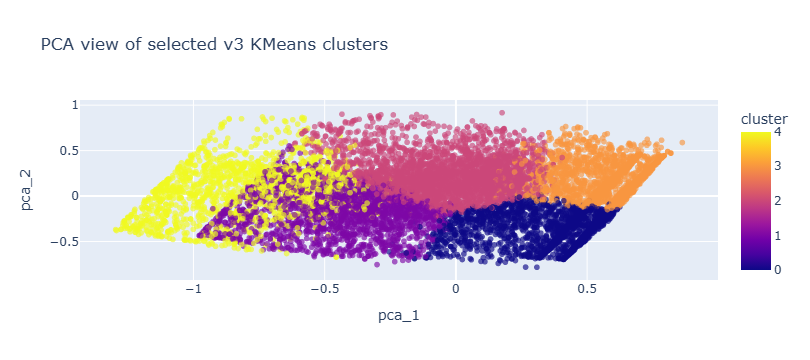

In [22]:
fig = px.scatter(
    pca_2d_df,
    x="pca_1",
    y="pca_2",
    color="cluster",
    title="PCA view of selected v3 KMeans clusters",
    opacity=0.65,
    hover_data=[
        "cluster",
        "company_name",
        "ticker",
        "fiscal_year",
    ],
)


fig.show()

In [23]:
pca_3d = PCA(n_components=3, random_state=DEFAULT_RANDOM_STATE)

X_pca_3d = pca_3d.fit_transform(X_prepared)

pca_3d_df = clustered_panel[
    ["ticker", "company_name", "fiscal_year", DEFAULT_SEGMENT_COL, "cluster"]
].copy()

pca_3d_df["pca_1"] = X_pca_3d[:, 0]
pca_3d_df["pca_2"] = X_pca_3d[:, 1]
pca_3d_df["pca_3"] = X_pca_3d[:, 2]

print("PCA 3D explained variance ratio:")
print(pca_3d.explained_variance_ratio_)
print("Total explained variance:", pca_3d.explained_variance_ratio_.sum())

PCA 3D explained variance ratio:
[0.50288417 0.23482975 0.09370073]
Total explained variance: 0.8314146495194229


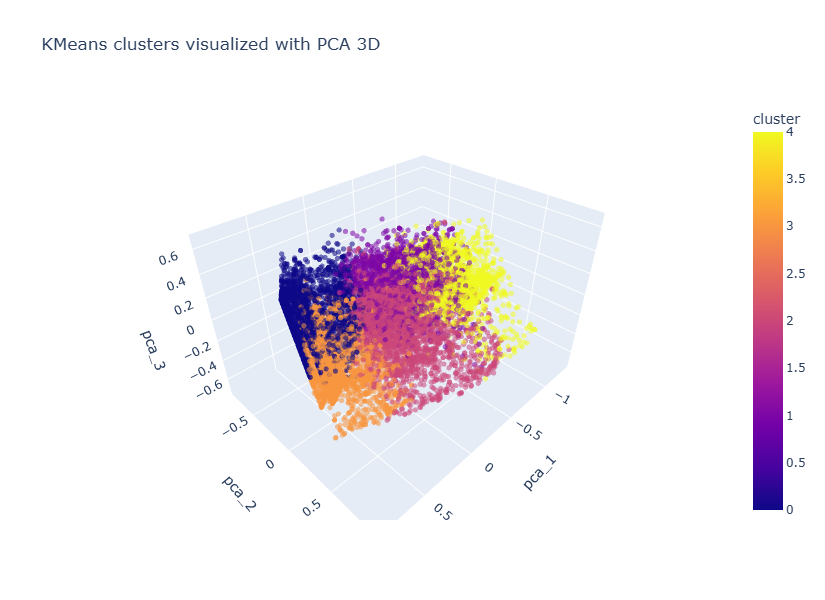

In [24]:
fig = px.scatter_3d(
    pca_3d_df,
    x="pca_1",
    y="pca_2",
    z="pca_3",
    color="cluster",
    hover_data=["ticker", "company_name", "fiscal_year"],
    title="KMeans clusters visualized with PCA 3D",
    opacity=0.55,
)

fig.update_traces(marker=dict(size=3))

fig.update_layout(
    width=800,
    height=600,
)

fig.show()

### 8. Save outputs and model artifact

Artifact schema/persistence lives in `src.credit_clustering.artifacts.py`.

This final step saves the trained model and the supporting interpretation outputs into a reusable project artifact. The artifact logic is centralized in `src.credit_clustering.artifacts.py`, which keeps the notebook focused on orchestration while the module handles artifact structure, validation, saving, loading, and summarization.

The saved artifact contains more than the fitted K-Means pipeline. It also preserves the feature columns used by the model, the selected primary segment, cluster sizes, model metrics, cluster profiles, ranked rating-style labels, risk-rank mappings, domain weights, component features, ratio columns, interpretation features, and additional profiling tables. This is important because Notebook 03 needs not only the trained model, but also the surrounding interpretation logic required to score and report a new company consistently.

The artifact is designed to support both a future multi-segment structure and the current single primary segment, which is `Non-financial`. Even though the current project clusters only non-financial issuers, the schema keeps a `segment_artifacts` structure so the project can later be extended to other segments if separate feature engineering is developed. At the same time, the artifact also keeps top-level aliases such as `pipeline`, `feature_cols`, `cluster_labels`, and `risk_rank` for backward compatibility with simpler Notebook 03 scoring logic.

Before saving, the artifact can be validated to confirm that the required scoring fields exist. It is then persisted with `joblib`, which allows the trained pipeline and all related metadata to be loaded later without rerunning the full training notebook. This makes the project operational: the model trained in Notebook 02 becomes a reusable scoring engine for Notebook 03 and for future private-company credit-profile analysis.


In [25]:
# ---------------------------------------------------------------------
# Save review / reporting outputs
# ---------------------------------------------------------------------
print("\nSaving review outputs...")

cluster_profile_ranked.to_csv(
    CURRENT_OUTPUT_DIR / f"cluster_profile_v3_by_{DEFAULT_SEGMENT_COL}.csv",
    index=False,
)

cluster_profile_ranked_with_reps.to_csv(
    CURRENT_OUTPUT_DIR / f"cluster_profile_with_reps_v3_by_{DEFAULT_SEGMENT_COL}.csv",
    index=False,
)

cluster_medians.to_csv(
    CURRENT_OUTPUT_DIR / f"cluster_medians_v3_by_{DEFAULT_SEGMENT_COL}.csv"
)

feature_extremes.to_csv(
    CURRENT_OUTPUT_DIR / "feature_extremes_v3.csv"
)

industry_cluster_mix.to_csv(
    CURRENT_OUTPUT_DIR / f"industry_cluster_mix_v3_by_{DEFAULT_SEGMENT_COL}.csv",
    index=False,
)

metrics_df.to_csv(
    CURRENT_OUTPUT_DIR / f"cluster_metrics_v3_by_{DEFAULT_SEGMENT_COL}.csv",
    index=False,
)

k_tests.to_csv(
    CURRENT_OUTPUT_DIR / f"cluster_k_tests_v3_by_{DEFAULT_SEGMENT_COL}.csv",
    index=False,
)

print("\nSaved review outputs to:", CURRENT_OUTPUT_DIR)


Saving review outputs...

Saved review outputs to: D:\users\kamen.dimitrov\desktop\SOFTUNI\AI_and_ML_upskill_program\Machine_learning\08_final_project_3\outputs\credit_clustering_outputs_v3


In [26]:
artifact = build_credit_clustering_artifact(
    segment_artifacts=segment_artifacts,
    cluster_profile_ranked=cluster_profile_ranked,
    primary_segment="Non-financial",
    segment_col=DEFAULT_SEGMENT_COL,
    metrics_df=metrics_df,
    cluster_profile=cluster_profile,
    cluster_medians=cluster_medians,
    feature_extremes=feature_extremes,
    industry_cluster_mix=industry_cluster_mix,
    winsor_caps=None,
    artifact_version="v3_scorecard",
    notes=(
        "V3 KMeans++ k=5 model trained on bounded directional credit-risk factors. "
        "Debt-service risk includes EBITDA-enhanced diagnostics where available, "
        "with legacy coverage/FCF fallback when EBITDA is unavailable. "
        "Absolute size is excluded from clustering and retained only as diagnostic flags. "
        "Labels are rating-style interpretations, not formal credit ratings."
    ),
    extra_metadata={
        "model_name": "nonfinancial_credit_scorecard_kmeans_k5",
        "training_rows": int(len(clustered_panel[clustered_panel[DEFAULT_SEGMENT_COL] == "Non-financial"])),
        "source_notebook": "02_credit_clustering.ipynb",
    },
)

saved_path = save_artifact(
    artifact,
    ARTIFACT_PATH,
    segment="Non-financial",
)

print("Saved model artifact to:", saved_path)
summarize_artifact(artifact, segment="Non-financial")

Saved model artifact to: D:\users\kamen.dimitrov\desktop\SOFTUNI\AI_and_ML_upskill_program\Machine_learning\08_final_project_3\outputs\saved_models\nonfinancial_credit_scorecard_kmeans_k5_v3.joblib


{'artifact_version': 'v3_scorecard',
 'primary_segment': 'Non-financial',
 'segment': 'Non-financial',
 'feature_cols': ['earnings_risk',
  'structural_distress_risk',
  'operating_cashflow_risk',
  'liquidity_risk',
  'debt_service_risk',
  'leverage_risk'],
 'n_clusters': 5,
 'cluster_labels': {4: '1 - Strong relative credit profile',
  1: '2 - Good credit profile',
  2: '3 - Leveraged / elevated risk profile',
  0: '4 - Weak credit profile',
  3: '5 - Distressed / near-default proxy'},
 'risk_rank': {4: 1, 1: 2, 2: 3, 0: 4, 3: 5},
 'cluster_sizes': {0: 2714, 1: 2048, 2: 3418, 3: 2354, 4: 1640},
 'silhouette': 0.2633227982622144,
 'calinski_harabasz': 4862.609080423672,
 'davies_bouldin': 1.3252994928493005}

In [27]:
CLUSTERED_PANEL_PATH = (
    CURRENT_OUTPUT_DIR / f"clustered_panel_v3_by_{DEFAULT_SEGMENT_COL}.csv"
)

clustered_panel.to_csv(CLUSTERED_PANEL_PATH, index=False)

print("Saved clustered panel to:", CLUSTERED_PANEL_PATH)

Saved clustered panel to: D:\users\kamen.dimitrov\desktop\SOFTUNI\AI_and_ML_upskill_program\Machine_learning\08_final_project_3\outputs\credit_clustering_outputs_v3\clustered_panel_v3_by_financial_flag.csv


### 9. Handoff to Notebook 02 and Notebook 03

At this stage, the main K-Means training workflow produces a saved model artifact that contains the fitted pipeline, the selected model features, the cluster profiles, the rating-style labels, the risk-rank mappings, and the supporting interpretation metadata. This artifact becomes the bridge between model development and later application.

The next notebook, Notebook 02, is used as an additional validation and comparison layer. Its purpose is not to replace the selected K-Means model, but to test whether alternative unsupervised approaches tell a broadly similar story. In that notebook, I review agglomerative clustering and DBSCAN as governance checks. Agglomerative clustering helps assess whether the financial-risk observations have a hierarchical structure, while DBSCAN helps test whether the data contains dense regions and potential outlier groups. These methods are useful for comparison, but the main model remains K-Means because it provides interpretable centroids, stable cluster assignment, and a practical way to score new companies.

Notebook 03 is the application notebook. It loads the saved artifact and applies the trained model to manually entered or private-company financial data. The scoring workflow uses `score_companies()` together with the diagnostics utilities to transform raw financial inputs into the same engineered feature space used during training, assign the company to one of the trained clusters, calculate distance and affinity diagnostics, apply guardrail checks, and produce the final Excel and PDF reporting outputs.

This separation keeps the project workflow clean. The current notebook trains and saves the production K-Means artifact. Notebook 02 challenges the modelling decision through alternative clustering methods. Notebook 03 then uses the saved artifact as a practical scoring engine for business application. In this way, the project moves from model construction, to methodological challenge, to real-world use. Notebook 03 will load the saved artifact and use `score_companies()` plus `diagnostics.py` utilities for manual/private-company scoring.

## Conclusion

This notebook completes the main model construction stage of the Corporate Credit Clustering Tool. The objective was to transform public SEC EDGAR financial statement data into a structured credit-risk feature space and use unsupervised learning to group non-financial corporate issuer-year observations into interpretable credit-profile buckets.

The final model uses six bounded, directionally aligned credit-risk features: structural distress risk, earnings risk, operating cash-flow risk, liquidity risk, leverage risk, and debt-service risk. These features are not raw accounting values. They are engineered from financial ratios and professional credit-analysis logic so that the model works in a financially meaningful space before K-Means is applied.

The final K-Means configuration uses five clusters. This choice was not made mechanically from one internal metric. It reflects a balance between statistical diagnostics, business interpretability, and the practical need for a five-level relative credit-risk scale. The cluster profiling step showed a coherent progression from stronger companies with positive profitability, cash flow, and debt-service capacity to weaker companies with negative profitability, weak coverage, thin equity buffers, and structural distress signals.

The model also confirms an important methodological point: corporate credit quality is not naturally divided into perfectly separated groups. It behaves more like a continuous risk spectrum. For that reason, the clusters should not be interpreted as formal credit ratings or probability-of-default estimates. They are model-relative credit-risk buckets designed for screening, benchmarking, exploratory analysis, and analyst support.

A key result of this notebook is the saved model artifact. The artifact contains the fitted pipeline, selected feature columns, cluster profiles, rating-style labels, risk-rank mappings, metrics, and interpretation metadata. This makes the model reusable outside the training notebook. Notebook 02 will use alternative clustering methods such as agglomerative clustering and DBSCAN as governance checks, while Notebook 03 will load the saved artifact and apply it to manual or private-company scoring.

Overall, the work in this notebook supports the main project thesis: it is possible to combine professional credit-analysis logic with unsupervised machine learning to produce a transparent, reproducible, and interpretable credit-risk benchmarking tool. The result is not a replacement for professional credit judgment, but it is a practical analytical engine that can support structured comparison of corporate credit profiles and serve as a foundation for further development.